# Alignment Sandbox

Notebook for running the Milestone 1 alignment benchmark pipeline on local Mazurka data.

The benchmark now uses directed `reference__query` cases. The reference is the stored template performance, the query is the simulated live performance, and the beat-based metrics score how accurately the alignment predicts reference time from query time.

In [43]:
import importlib
from pathlib import Path
import sys
import pandas as pd
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()
PROJECT_ROOT = NOTEBOOK_DIR if (NOTEBOOK_DIR / "scripts").exists() else NOTEBOOK_DIR.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from scripts import config, data_io, online_baselines, oltw, evaluation, visualization

config = importlib.reload(config)
data_io = importlib.reload(data_io)
online_baselines = importlib.reload(online_baselines)
oltw = importlib.reload(oltw)
evaluation = importlib.reload(evaluation)
visualization = importlib.reload(visualization)

## 1. Discover Local Data

The loader supports a manifest, the split Mazurka layout under `data/raw/wav_22050_mono/` and `data/raw/annotations_beat/`, or an inferred directory layout. `build_recording_pairs(...)` now returns directed benchmark cases, so `A__B` and `B__A` are both present.

In [44]:
recordings = data_io.discover_recordings(config.RAW_DATA_DIR)
pairs = data_io.build_recording_pairs(recordings)
small_pairs = evaluation.select_recording_pairs(pairs, selection_mode="small") if pairs else []
len(recordings), len(pairs), len(small_pairs)

(301, 19392, 6)

## 2. Inspect the Preview Benchmark Case

The preview case is the fastest directed case inside the fixed `small` benchmark. `small` is a 3-recording preview set from the shortest eligible piece, which expands to 6 directed cases total.

In [45]:
if pairs:
    preview_pair = evaluation.select_preview_recording_pair(pairs)
    display({
        "piece": preview_pair.piece,
        "preview_pair_id": preview_pair.pair_id,
        "reference_recording": preview_pair.reference.recording_id,
        "query_recording": preview_pair.query.recording_id,
        "small_benchmark_case_ids": [pair.pair_id for pair in small_pairs],
    })
else:
    print("No local benchmark cases found. Add data under data/raw/ first.")

{'piece': 'Chopin_Op030No2',
 'preview_pair_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'reference_recording': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
 'query_recording': 'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'small_benchmark_case_ids': ['Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
  'Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
  'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15__Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
  'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15__Chopin_Op030No2_Ashkenazy-1982_pid50848-03',
  'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Ashkenazy-1982_pid50848-03',
  'Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Chopin_Op030No2_Ashkenazy-1981_pid9058-19']}

## 3. Run One Preview Alignment

This runs one directed `reference <- query` alignment with a selectable benchmark method and computes beat-based tracking metrics at query beat times.

In [46]:
if pairs:
    benchmark_method = "offline_dtw"  # "offline_dtw", "oltw", or "oltw_global"
    preview_pair = evaluation.select_preview_recording_pair(pairs)
    alignment_result, metric_row = evaluation.evaluate_recording_pair(
        preview_pair,
        method_name=benchmark_method,
    )
    display(metric_row)
else:
    print("Skipping alignment because no benchmark cases were discovered.")

{'method_name': 'offline_dtw',
 'reference_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19',
 'query_id': 'Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'num_beats_used': 193,
 'mean_error_s': -0.0002669718374398059,
 'mean_abs_error_s': 0.05999344047325281,
 'median_abs_error_s': 0.021383544217687955,
 'rmse_s': 0.13412475247162797,
 'max_abs_error_s': 1.184217873015875,
 'p95_abs_error_s': 0.25494766213152076,
 'within_50ms': 0.7305699481865285,
 'within_100ms': 0.8393782383419689,
 'within_200ms': 0.9326424870466321,
 'piece': 'Chopin_Op030No2',
 'pair_id': 'Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Chopin_Op030No2_Sofronitsky-1960_pid5667291-15',
 'feature_name': 'chroma_stft'}

## 4. Visualize the Alignment Path

The x-axis is reference time and the y-axis is query time. For the live-tracking benchmark, the downstream metric uses this path to predict reference time from the current query time.

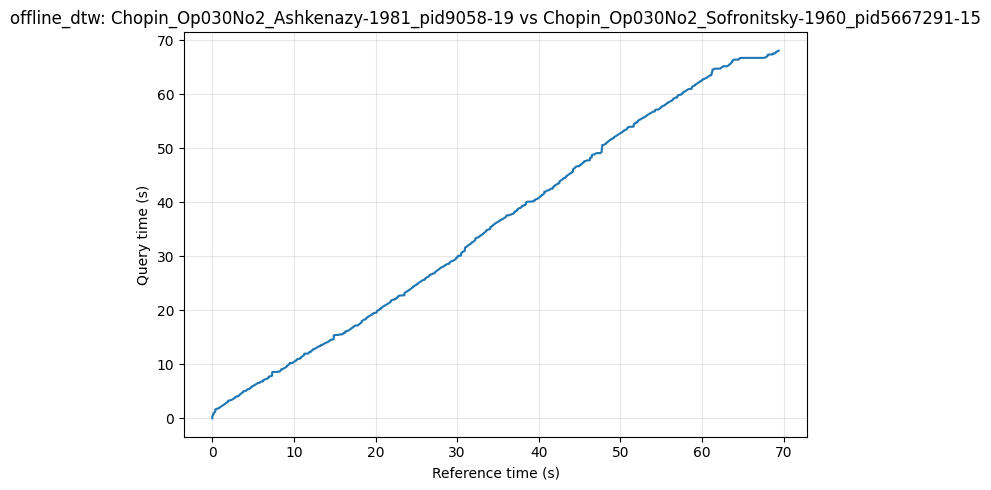

In [47]:
if "alignment_result" in locals():
    visualization.plot_alignment_path(alignment_result)
else:
    print("Run the alignment cell first.")

## 5. Compare Small Benchmarks

By default, the `small` benchmark runs both `offline_dtw` and `oltw` on the same 6 directed cases so you can compare method-level averages and per-pair results side by side. You can still switch to `single` or `full` mode, but those run only the selected `benchmark_method`.

In [48]:
if pairs:
    benchmark_method = "offline_dtw"  # used for "single" and "full" modes
    benchmark_mode = "small"  # "single", "small", or "full"
    benchmark_pair_id = None
    benchmark_methods = ["offline_dtw", "oltw"] if benchmark_mode == "small" else [benchmark_method]
    if benchmark_mode == "single":
        benchmark_pair_id = evaluation.select_preview_recording_pair(pairs).pair_id

    benchmark_frames = []
    for benchmark_method in benchmark_methods:
        benchmark_frame = evaluation.run_alignment_benchmark(
            dataset_root=config.RAW_DATA_DIR,
            output_dir=config.METRICS_DIR,
            experiment_name=f"{benchmark_method}_notebook_{benchmark_mode}",
            method_name=benchmark_method,
            selection_mode=benchmark_mode,
            pair_id=benchmark_pair_id,
            save_outputs=True,
            show_progress=True,
        )
        benchmark_frames.append(benchmark_frame)

    metrics_frame = pd.concat(benchmark_frames, ignore_index=True)
    comparison_summary = (
        metrics_frame.groupby("method_name", dropna=False)
        .agg(
            num_pairs=("pair_id", "size"),
            mean_mae_s=("mean_abs_error_s", "mean"),
            mean_rmse_s=("rmse_s", "mean"),
            mean_within_100ms=("within_100ms", "mean"),
            mean_within_200ms=("within_200ms", "mean"),
        )
        .reset_index()
        .sort_values("mean_mae_s")
    )
    display(comparison_summary)
    display(
        metrics_frame[
            [
                "method_name",
                "pair_id",
                "mean_abs_error_s",
                "rmse_s",
                "within_100ms",
                "within_200ms",
            ]
        ].sort_values(["method_name", "mean_abs_error_s"])
    )
else:
    print("No benchmark cases discovered, so the benchmark was skipped.")

offline_dtw_notebook_small:   0%|          | 0/6 [00:00<?, ?it/s]

oltw_notebook_small:   0%|          | 0/6 [00:00<?, ?it/s]

,method_name,num_pairs,mean_mae_s,mean_rmse_s,mean_within_100ms,mean_within_200ms
0,offline_dtw,6,0.041305,0.088665,0.886010,0.946459
1,oltw,6,4.458761,6.072235,0.700345,0.744387


,method_name,pair_id,mean_abs_error_s,rmse_s,within_100ms,within_200ms
5,offline_dtw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,0.005521,0.008078,1.000000,1.000000
4,offline_dtw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,0.005521,0.008078,1.000000,1.000000
1,offline_dtw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,0.058787,0.132723,0.834197,0.922280
3,offline_dtw,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,0.058790,0.124713,0.823834,0.911917
2,offline_dtw,Chopin_Op030No2_Sofronitsky-1960_pid5667291-15...,0.059222,0.124273,0.818653,0.911917
0,offline_dtw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,0.059993,0.134125,0.839378,0.932642
11,oltw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,0.005521,0.008078,1.000000,1.000000
10,oltw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,0.005521,0.008078,1.000000,1.000000
7,oltw,Chopin_Op030No2_Ashkenazy-1982_pid50848-03__Ch...,0.063814,0.157762,0.834197,0.922280
6,oltw,Chopin_Op030No2_Ashkenazy-1981_pid9058-19__Cho...,0.064331,0.155490,0.839378,0.932642


## 6. Read the Metrics

Each benchmark row is evaluated at beat landmarks. For each query beat time, the alignment path estimates the corresponding reference time, and the benchmark compares that estimate against the annotated reference beat time.

- `mean_error_s`: signed average error. Positive means the tracker tends to predict a reference position that is too far ahead; negative means it tends to lag behind.
- `mean_abs_error_s`: average absolute error. This is the easiest single number for overall tracking accuracy.
- `median_abs_error_s`: typical absolute error, with less sensitivity to a few bad failures.
- `rmse_s`: root mean squared error. This penalizes larger misses more heavily than `mean_abs_error_s`.
- `max_abs_error_s`: worst beat-level error in the case.
- `p95_abs_error_s`: 95th percentile absolute error. Most beat errors fall below this value.
- `within_50ms`, `within_100ms`, `within_200ms`: fraction of evaluated beats whose absolute error stays within each tolerance.

Interpret `mean_error_s` as bias, not overall quality. A value near zero can still hide large mistakes if early and late errors cancel out. For accuracy, focus first on `mean_abs_error_s`, `rmse_s`, and the `within_*` columns.

## 7. Plot the Benchmark Summary

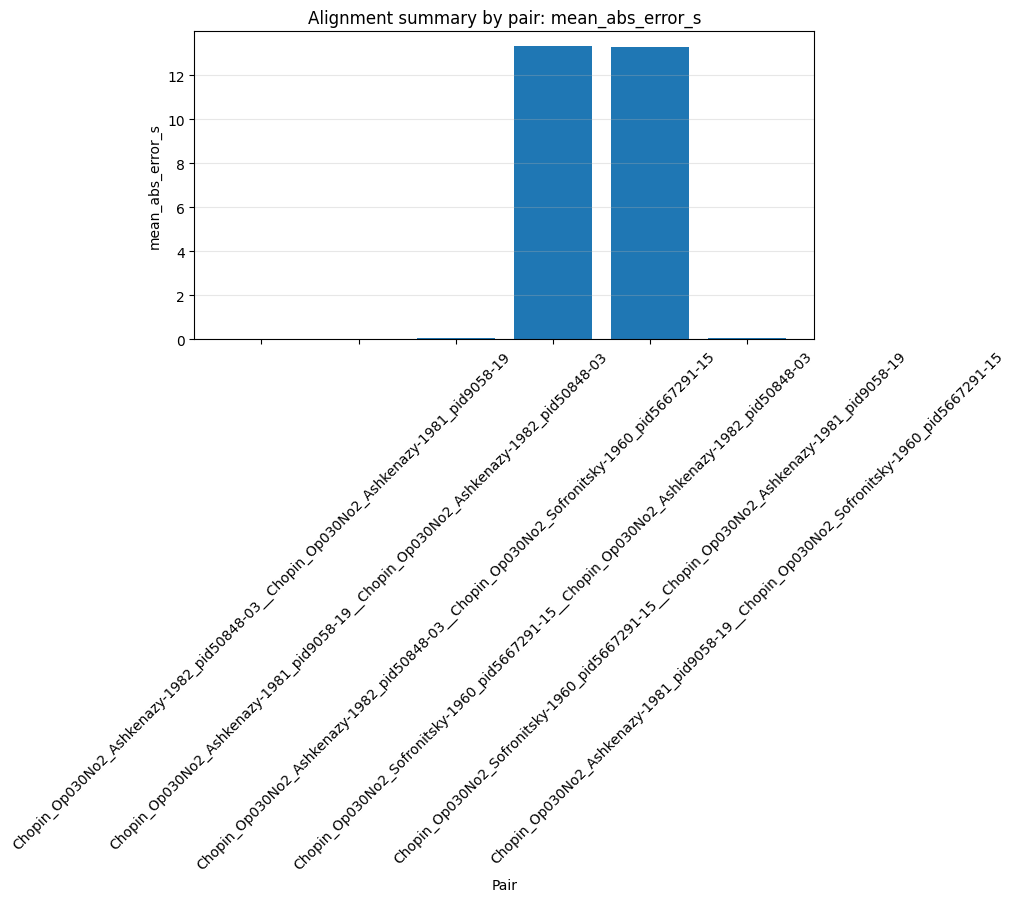

In [50]:
if "metrics_frame" in locals():
    visualization.plot_error_summary(metrics_frame)
else:
    print("Run a benchmark cell first.")